# Inspect Magnusson et al., 2025 Data

In [1]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

base_dir = "/Users/jakobwerkgarner/code/mt_dsnow"

os.chdir(base_dir)


In [2]:
ds = xr.open_dataset("calibration/calibration_data/raw_data/Mag25/SLF_dataset/Mag25_all.nc")

In [3]:
# calculate rho_0

rho0 = (ds["HNW"] / ds["HN"]).where(ds["HN"] > 0)

mean_rho0 = float(rho0.mean(skipna=True))



stations = ds["station"].values

rho0_by_station = [
    rho0.sel(station=st).values[~np.isnan(rho0.sel(station=st).values)]
    for st in stations
]

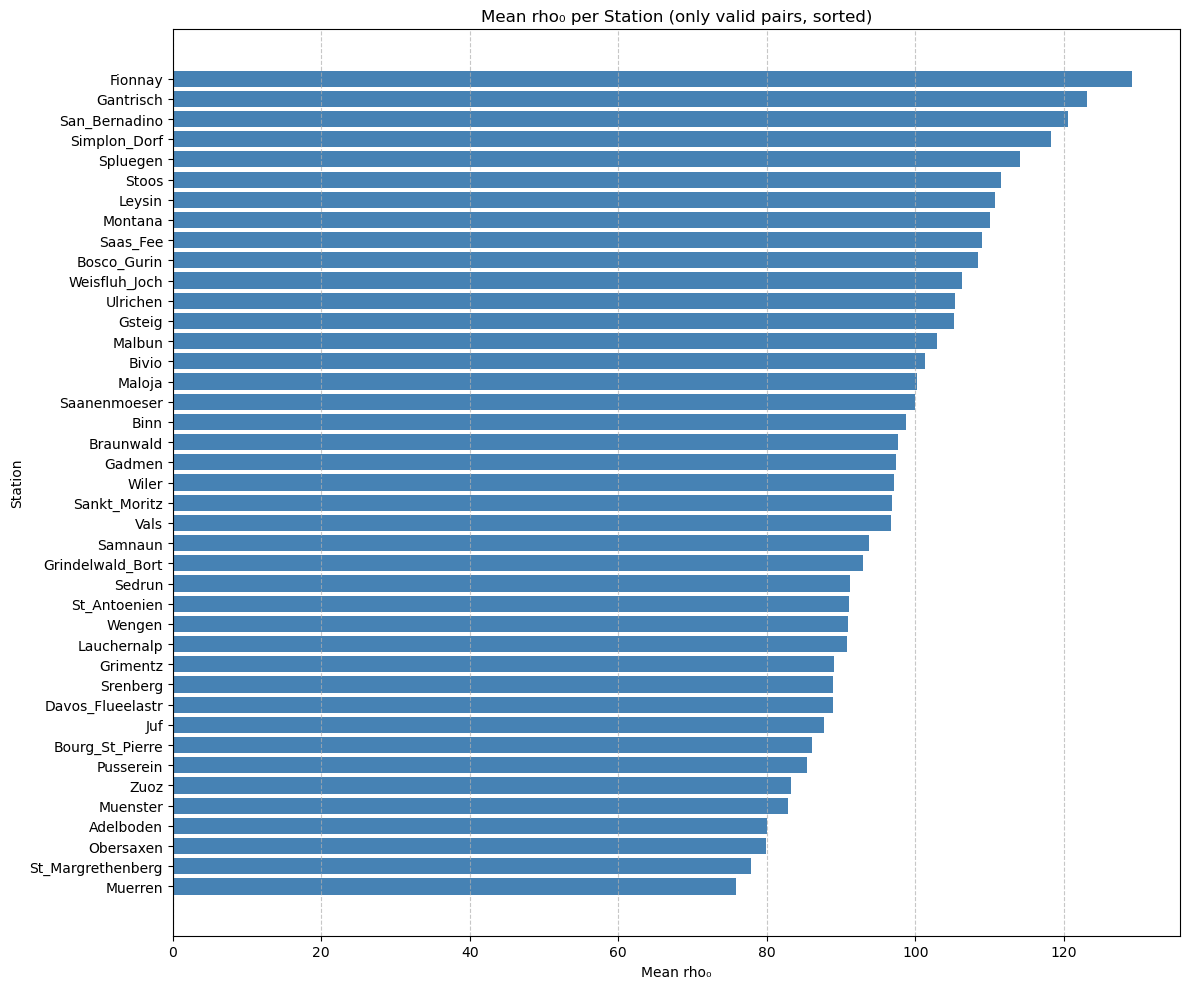

In [4]:
## Check the new snow swe by station 

# Compute rho0 only where both HNW and HN are valid
rho0 = ds.HNW / ds.HN
rho0 = rho0.where(ds.HNW.notnull() & ds.HN.notnull())

# Mean across time, skipping NaNs
mean_rho_0 = rho0.mean(dim="time", skipna=True)

# Sort stations by mean_rho_0
mean_rho_0_sorted = mean_rho_0.sortby(mean_rho_0)

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(mean_rho_0_sorted.station.values, mean_rho_0_sorted.values, color="steelblue")

# Formatting
ax.set_xlabel("Mean rho₀")
ax.set_ylabel("Station")
ax.set_title("Mean rho₀ per Station (only valid pairs, sorted)")
ax.grid(axis="x", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

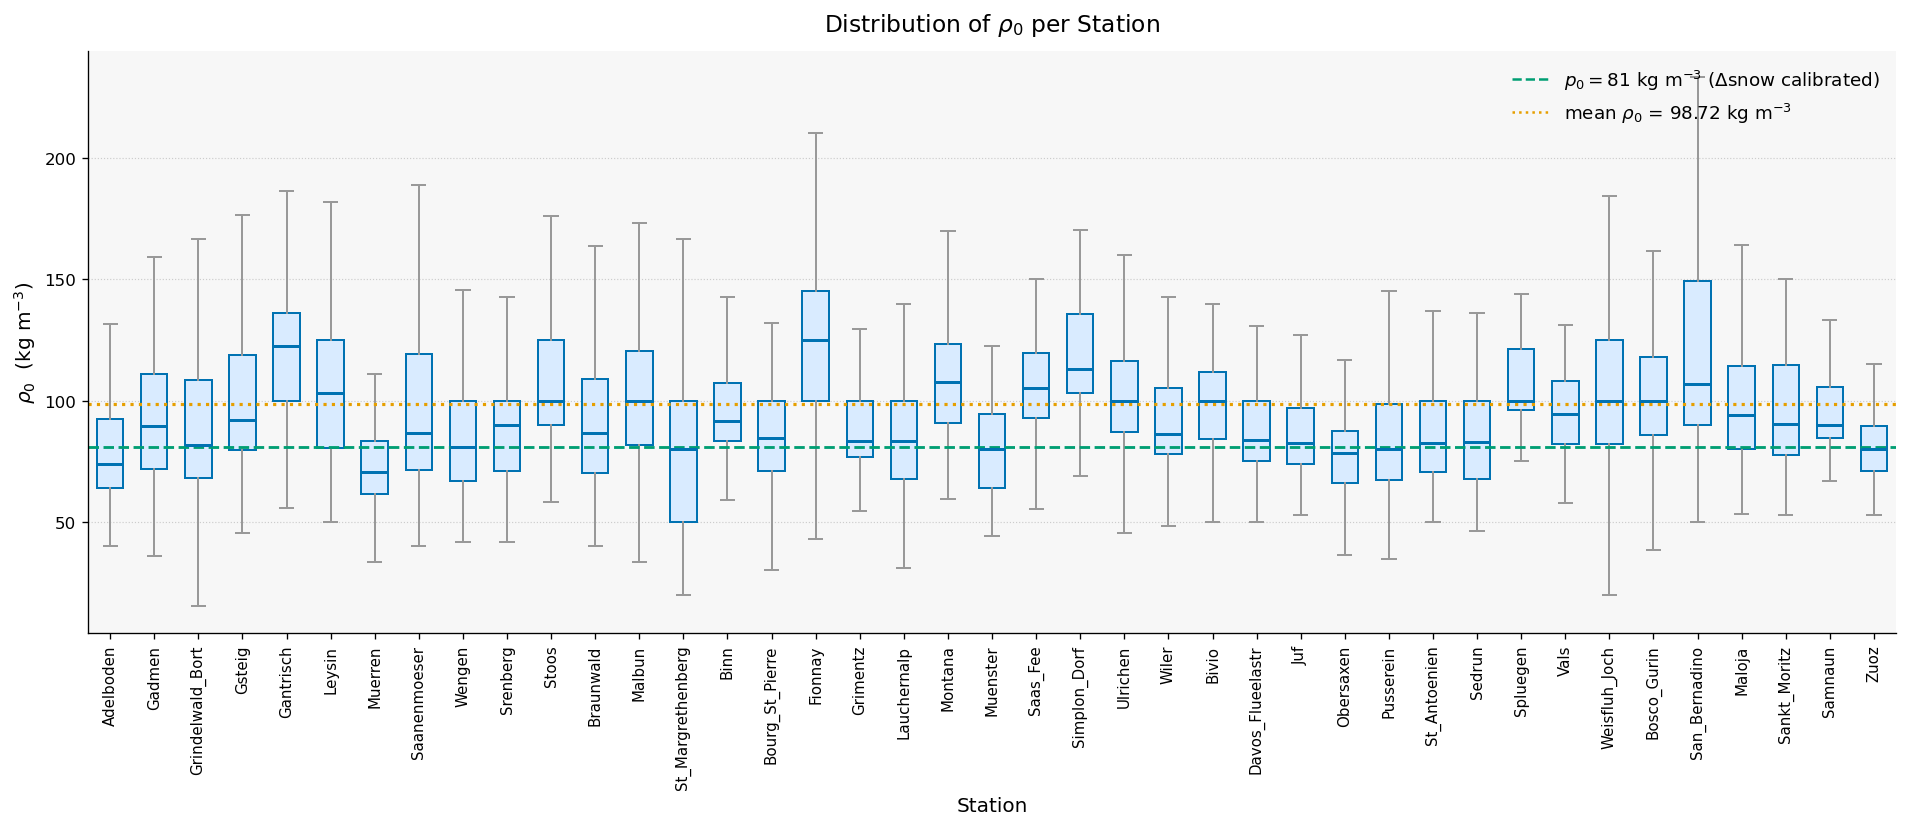

In [5]:
# --- Colorblind-safe palette (Okabe–Ito), distinct choices ---
CB_BLUE   = "#0072B2"  # blue
CB_ORANGE = "#E69F00"  # orange
CB_GREEN  = "#009E73"  # green
CB_GREY   = "#999999"  # grey

# --- Figure style ---
plt.style.use("default")
fig, ax = plt.subplots(figsize=(16, 7), dpi=120)

# Light background
ax.set_facecolor("#F7F7F7")
fig.patch.set_facecolor("#FFFFFF")

# Optional: modern look – hide top/right spines
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# --- Boxplot ---
bp = ax.boxplot(
    rho0_by_station,
    patch_artist=True,
    showfliers=False,
    widths=0.6,
    medianprops=dict(color=CB_BLUE, linewidth=1.8),
    whiskerprops=dict(color=CB_GREY, linewidth=1.2),
    capprops=dict(color=CB_GREY, linewidth=1.2),
    boxprops=dict(
        facecolor="#D9EBFF",      # light, desaturated blue fill
        edgecolor=CB_BLUE,
        linewidth=1.2
    )
)

# --- X-axis labels ---
ax.set_xticks(np.arange(1, len(stations) + 1))
ax.set_xticklabels(stations, rotation=90, fontsize=9)
ax.tick_params(axis="y", labelsize=10)

# --- Labels & Title (with units) ---
# change units if rho0 is dimensionless, e.g. "[–]"
ax.set_ylabel(r"$\rho_0$  (kg m$^{-3}$)", fontsize=12)
ax.set_xlabel("Station", fontsize=12)
ax.set_title(r"Distribution of $\rho_0$ per Station", fontsize=14, pad=12)

# --- Grid (light & clean) ---
ax.grid(axis="y", linestyle=":", linewidth=0.7, color="#CCCCCC")
ax.set_axisbelow(True)

# --- Reference lines ---
# p_0 = 81: Δsnow calibrated value
p0 = 81.0
ax.axhline(p0, linestyle="--", linewidth=1.7, color=CB_GREEN)

# Mean rho0 line
ax.axhline(mean_rho0, linestyle=":", linewidth=1.9, color=CB_ORANGE)

# --- Legend ---
line_p0 = mlines.Line2D(
    [], [], linestyle="--", color=CB_GREEN,
    label=r"$p_0 = 81$ kg m$^{-3}$ (Δsnow calibrated)"
)
line_mean = mlines.Line2D(
    [], [], linestyle=":", color=CB_ORANGE,
    label=rf"mean $\rho_0$ = {mean_rho0:.2f} kg m$^{{-3}}$"
)

ax.legend(handles=[line_p0, line_mean], loc="upper right",
          frameon=False, fontsize=11)



plt.tight_layout()
plt.show()

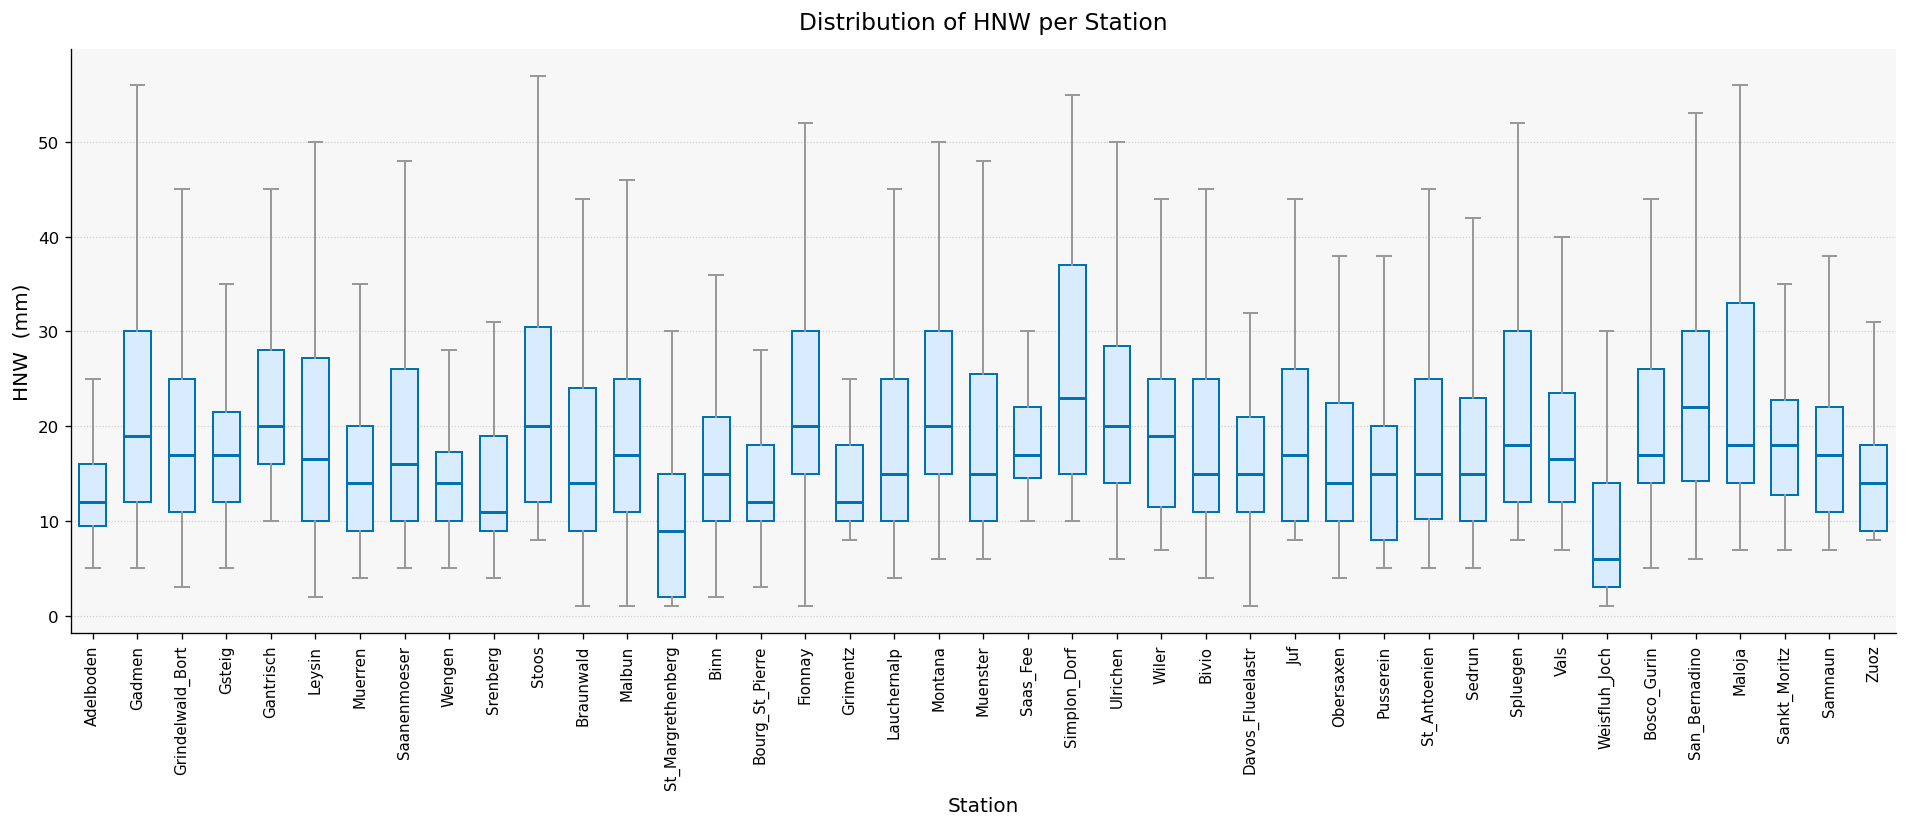

In [13]:
# Boxplot for HNW by station using colorblind-safe palette

plt.style.use("default")
fig, ax = plt.subplots(figsize=(16, 7), dpi=120)

# Light background
ax.set_facecolor("#F7F7F7")
fig.patch.set_facecolor("#FFFFFF")

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# Prepare HNW data by station (exclude NaNs)
hnw_by_station = [
    ds["HNW"].sel(station=st).values[
        (~np.isnan(ds["HNW"].sel(station=st).values)) & (ds["HNW"].sel(station=st).values != 0)
    ]
    for st in stations
]


bp = ax.boxplot(
    hnw_by_station,
    patch_artist=True,
    showfliers=False,
    widths=0.6,
    medianprops=dict(color=CB_BLUE, linewidth=1.8),
    whiskerprops=dict(color=CB_GREY, linewidth=1.2),
    capprops=dict(color=CB_GREY, linewidth=1.2),
    boxprops=dict(
        facecolor="#D9EBFF",
        edgecolor=CB_BLUE,
        linewidth=1.2
    )
)

ax.set_xticks(np.arange(1, len(stations) + 1))
ax.set_xticklabels(stations, rotation=90, fontsize=9)
ax.tick_params(axis="y", labelsize=10)

ax.set_ylabel(r"HNW  (mm)", fontsize=12)
ax.set_xlabel("Station", fontsize=12)
ax.set_title(r"Distribution of HNW per Station", fontsize=14, pad=12)

ax.grid(axis="y", linestyle=":", linewidth=0.7, color="#CCCCCC")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

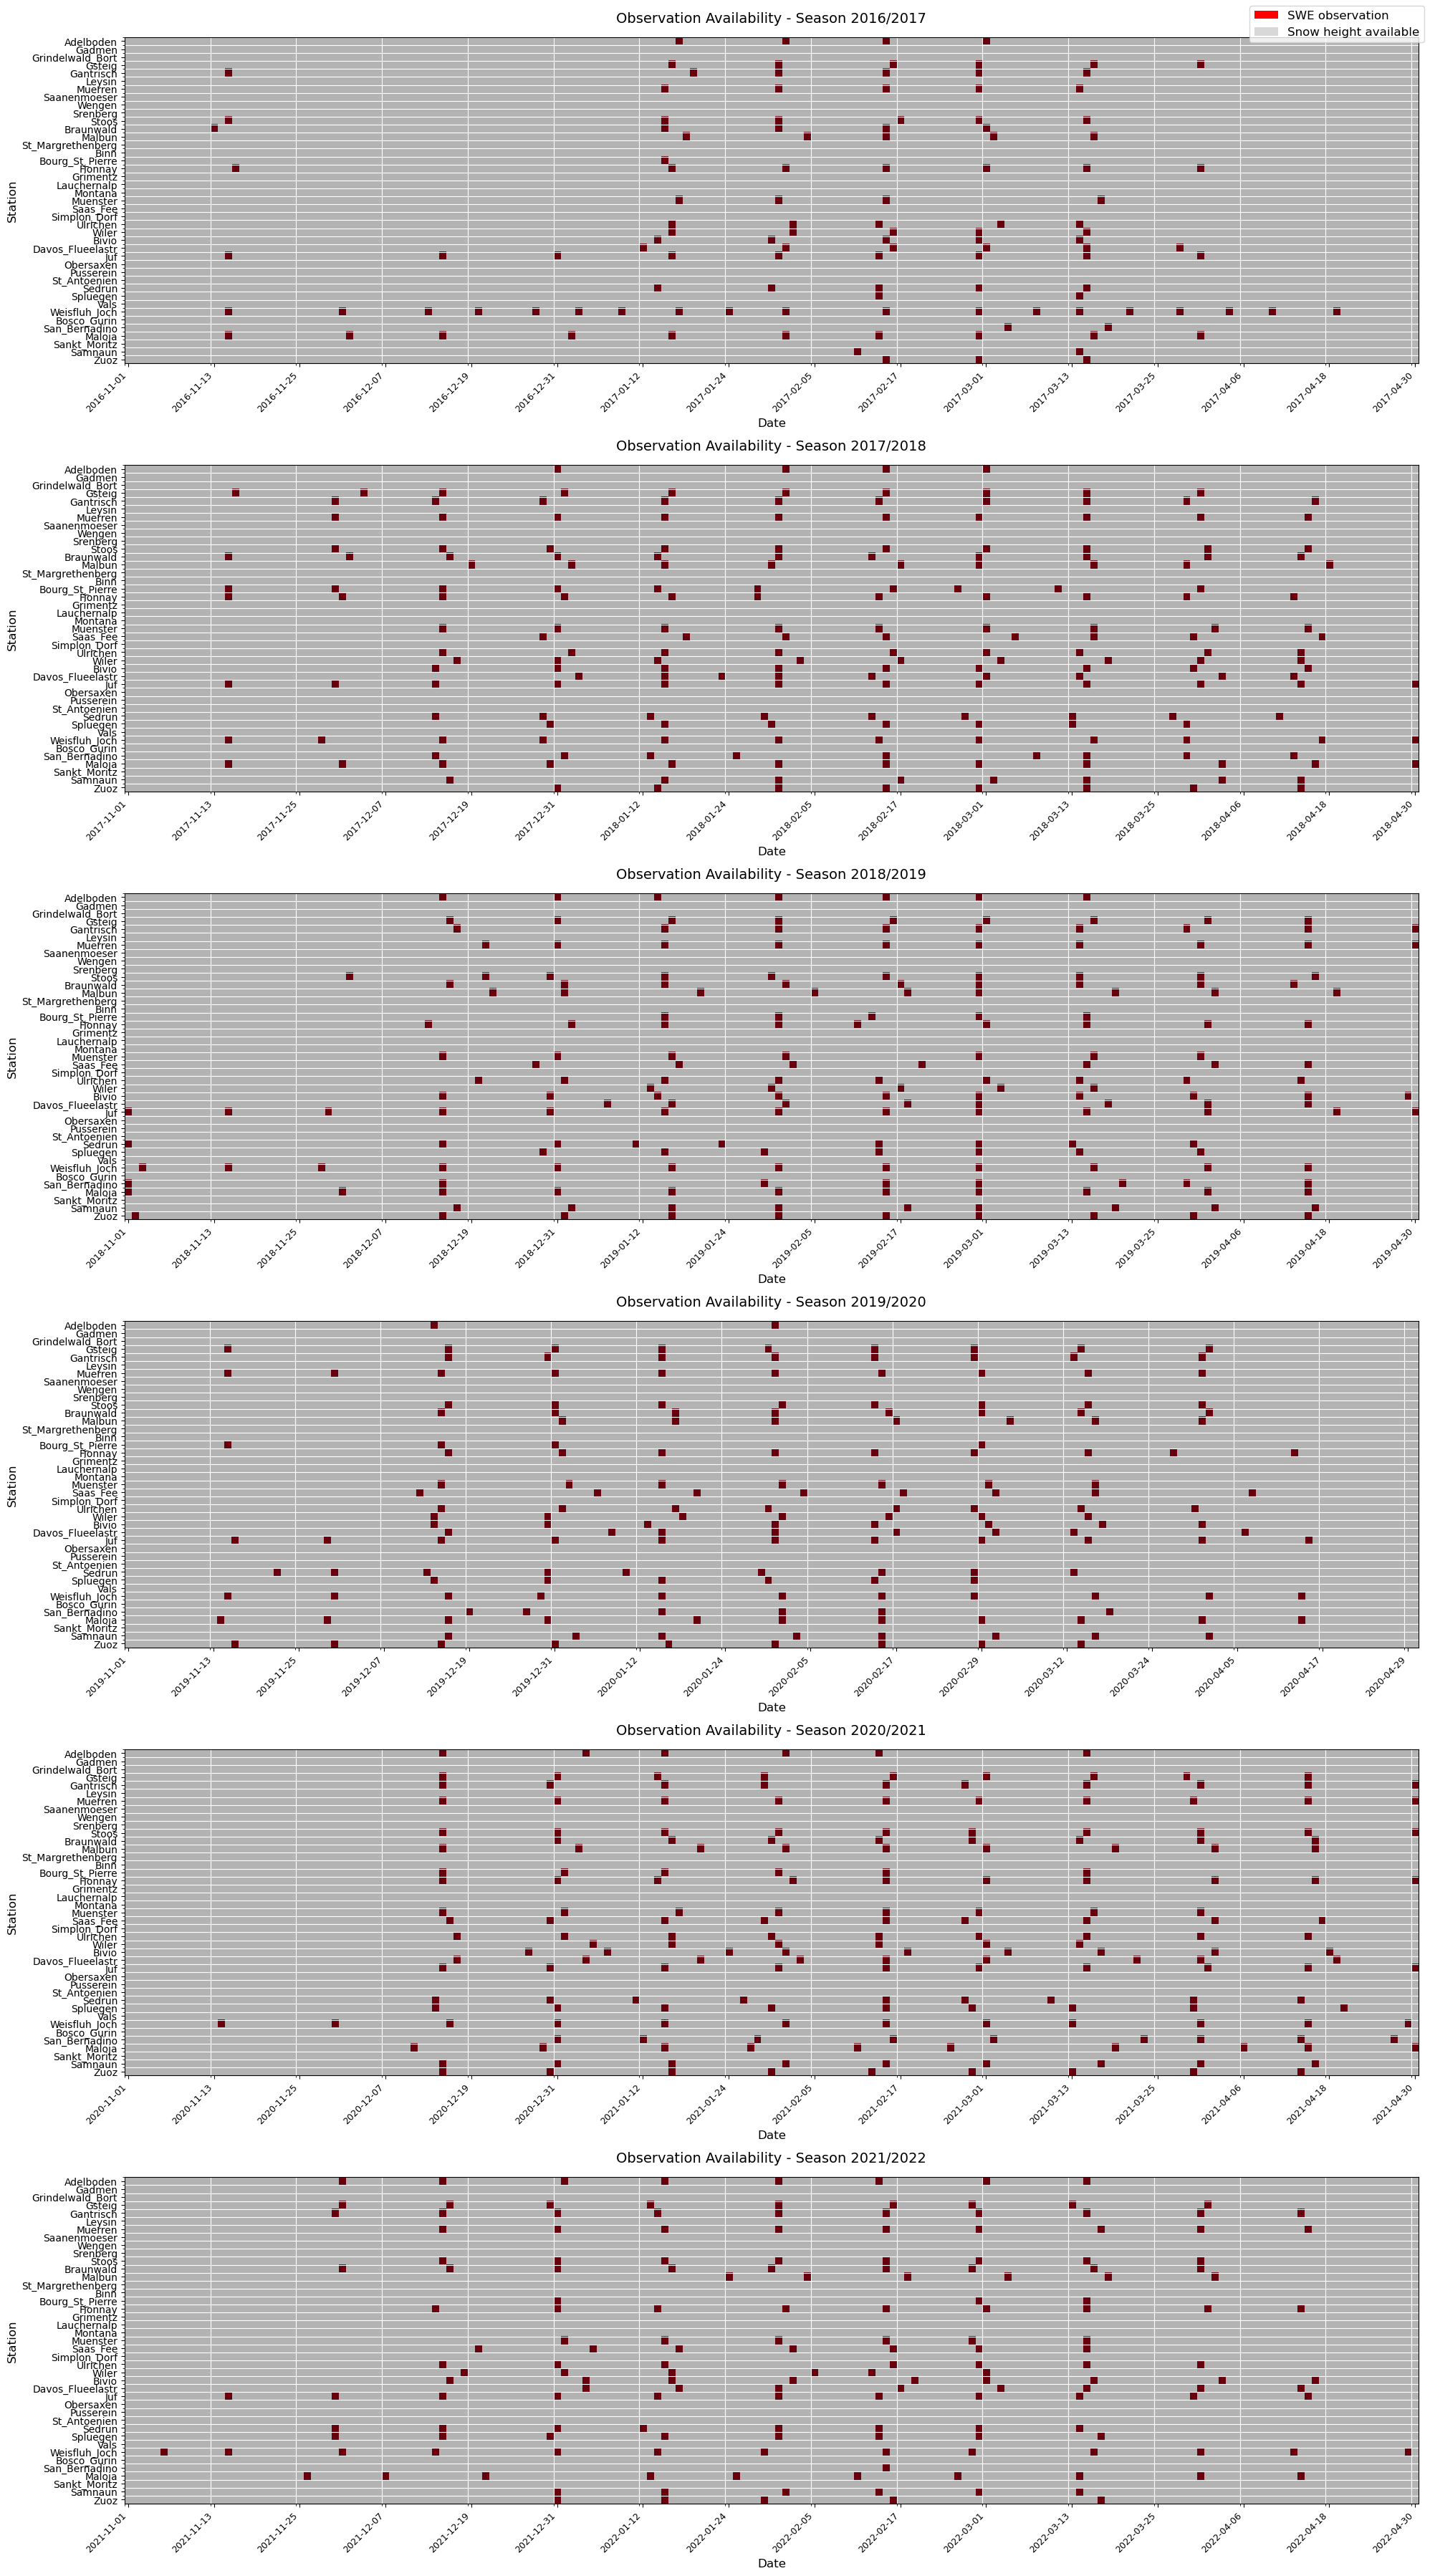

In [6]:
import pandas as pd
from matplotlib.patches import Patch
import numpy as np

# Create a calendar-like visualization showing when SWE and snow height observations are available
# One plot per season (Nov 1 - Apr 30)

# Convert time to pandas datetime for easier season extraction
time_df = pd.DataFrame({'time': pd.to_datetime(ds['time'].values)})
time_df['year'] = time_df['time'].dt.year
time_df['month'] = time_df['time'].dt.month

# Define seasons: Nov 1 to Apr 30
# Season year is based on the year when season starts (November)
def get_season(row):
    month = row['month']
    year = row['year']
    if month >= 11:  # Nov, Dec
        return f"{year}/{year+1}"
    elif month <= 4:  # Jan, Feb, Mar, Apr
        return f"{year-1}/{year}"
    else:
        return None  # Outside season

time_df['season'] = time_df.apply(get_season, axis=1)

# Filter to only include data within seasons
time_df = time_df[time_df['season'].notna()]

# Create availability masks - check for non-null values
swe_available = ds["SWE"].notnull().astype(int)
hs_available = ds["HS"].notnull().astype(int)

# Get unique seasons
seasons = time_df['season'].unique()

# Create subplots for each season with larger figure
n_seasons = len(seasons)
fig, axes = plt.subplots(n_seasons, 1, figsize=(20, 6*n_seasons))

if n_seasons == 1:
    axes = [axes]

for idx, season in enumerate(sorted(seasons)):
    ax = axes[idx]
    
    # Get time indices for this season
    season_mask = time_df['season'] == season
    season_times = time_df[season_mask]['time'].values
    season_indices = time_df[season_mask].index.values
    
    # Extract data for this season
    hs_season = hs_available.isel(time=season_indices)
    swe_season = swe_available.isel(time=season_indices)
    
    # Plot HS as light gray background shading
    im1 = ax.imshow(
        hs_season.T,
        aspect="auto",
        cmap="Greys",
        interpolation="nearest",
        vmin=0,
        vmax=1,
        alpha=0.3
    )
    
    # Plot SWE as red marks - mask where SWE is not available (0)
    swe_masked = np.ma.masked_where(swe_season.T == 0, swe_season.T)
    im2 = ax.imshow(
        swe_masked,
        aspect="auto",
        cmap="Reds",
        interpolation="none",
        vmin=0,
        vmax=1,
        alpha=1.0
    )
    
    # Set ticks and labels
    ax.set_yticks(np.arange(len(stations)))
    ax.set_yticklabels(stations, fontsize=10)
    
    # Format x-axis with dates
    n_times_season = len(season_times)
    step_season = max(n_times_season // 15, 1)
    ax.set_xticks(np.arange(0, n_times_season, step_season))
    ax.set_xticklabels(
        [str(t)[:10] for t in season_times[::step_season]],
        rotation=45,
        ha="right",
        fontsize=9
    )
    
    # Labels and title
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel("Station", fontsize=12)
    ax.set_title(f"Observation Availability - Season {season}", fontsize=14, pad=15)
    
    # Grid
    ax.set_xticks(np.arange(0, n_times_season, step_season) - 0.5, minor=True)
    ax.set_yticks(np.arange(len(stations)) - 0.5, minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.8)

# Add legend
legend_elements = [
    Patch(facecolor='red', alpha=1.0, label='SWE observation'),
    Patch(facecolor='gray', alpha=0.3, label='Snow height available')
]
fig.legend(handles=legend_elements, loc='upper right', fontsize=12)

plt.tight_layout()

plt.savefig('calibration/calibration_data/raw_data/Mag25/viz_analysis/swe_hs_availability_calendar.png', dpi=300)
plt.show()